# HTDemucs - Spatially-Aware Fine-Tune on binauralMUSDB18

Fine-tunes the **full pre-trained HTDemucs backbone** on the binauralMUSDB18-HQ
dataset so that **HTDemucs itself learns to preserve the binaural spatial cues** —
*without* adding any `SpatialCueModule` head (that is the SA-HTDemucs approach).

The objective augments the original HTDemucs training loss with a
**sub-band ILD MSE** spatial term:

$$\mathcal{L} = \lambda_{\text{td}} \underbrace{\tfrac{1}{S}\sum_s \|\hat{s} - s\|_1}_{\text{time-domain L1}}
 + \lambda_{\text{ild}} \underbrace{\tfrac{1}{S}\sum_s \big\|\widehat{\text{ILD}}^{(s)} - \text{ILD}^{(s)}_{\text{gt}}\big\|_2^2}_{\text{sub-band ILD MSE}}
  + \lambda_{\text{itd}} \underbrace{\tfrac{1}{S}\sum_s \big\|\widehat{\text{ITD}}^{(s)} - \text{ITD}^{(s)}_{\text{gt}}\big\|_2^2}_{\text{sub-band ITD MSE}}$$

The first term is  the original HTDemucs objective, namely a plain time-domain L1 on the waveforms
(Rouard et al., 2022). It keeps separation quality at the original HTDemucs level. The second term is
the per-sub-band ILD MSE that drives the backbone to preserve the spatial cues of each source at the
higher frequencies. The third term is the per-sub-band ITD MSE that drives the backbone to preserve
the spatial cues of each source at the lower frequencies.

**Memory strategy** (HTDemucs ~80M params):
- `torch.cuda.amp` (FP16) — halves activation memory
- `ACCUM_STEPS` gradient accumulation — effective batch = `BATCH_SIZE × ACCUM_STEPS`

> **Prerequisite:** `pip install demucs`

In [1]:
import sys
from pathlib import Path

# Robustly locate the project root (the folder containing the `sahtdemucs` package)
_cwd = Path().resolve()
_project_root = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / 'sahtdemucs' / '__init__.py').exists()),
    _cwd.parent,
)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import math
import random
import time
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, random_split

import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from demucs.pretrained import get_model
from demucs.apply import apply_model
from sahtdemucs.dataset import MusdbSpatialDataset
from sahtdemucs.spatial import (
    compute_ild_bands, compute_ild_bands_mel,
    compute_itd_bands, compute_itd_bands_mel, mel_bin_assignment,
)

## Configuration

In [2]:
# ── Remote or local ───────────────────────────────────────────────────────────
remote   = True
training = False

# ── Paths ─────────────────────────────────────────────────────────────────────
if remote:
    DATASET_ROOT = Path("/nas/home/macerbi/Dataset/binauralMUSDB18HQ")
    CKPT_DIR     = Path("/nas/home/macerbi/sahtdemucs/runs/htdemucs_spatial_finetune")
else:
    DATASET_ROOT = Path(r"D:\Polimi\PhD\Dataset\binauralMUSDB18HQ")
    CKPT_DIR     = Path(r"H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\MSS & SSL\sahtdemucs\runs\htdemucs_spatial_finetune")

CKPT_DIR.mkdir(parents=True, exist_ok=True)

if training:
    _run_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
else:
    _run_ts = "20260703_142826"   # <-- set to the run you want to resume/evaluate
CKPT_PATH = CKPT_DIR / f"htdemucs_spatial_{_run_ts}.pt"

# ── Training hyper-parameters ─────────────────────────────────────────────────
N_EPOCHS    = 100
BATCH_SIZE  = 4    # increase to 2 only if VRAM > ~20 GB
ACCUM_STEPS = 4    # effective batch = 4
LR          = 5e-5 # fine-tuning: lower LR than original training
VALID_SPLIT = 0.2
CROPS_PER_TRACK = 4    # random segments drawn per training track each epoch
N_WORKERS   = 0

# ── Loss weights ──────────────────────────────────────────────────────────────
# Separation term = time-domain L1 only, exactly as in the original HTDemucs
# paper (Rouard et al., 2022)
LAMBDA_TD   = 1.0       # time-domain L1 (separation) - the original HTDemucs loss
LAMBDA_ILD  = 5e-4      # sub-band ILD MSE (spatial) - level cue
# ITD is expressed in samples², a much larger numerical scale than the ILD (dB²),
# so LAMBDA_ITD is typically 1–2 orders of magnitude smaller than LAMBDA_ILD.
# Set to 0.0 to train on ILD only.
LAMBDA_ITD  = 0.0      # sub-band ITD MSE (spatial) - time/phase cue

# Sub-band spatial-cue configuration (shared by the ILD and ITD terms so both
# have the same band layout) — mirrors the SA-HTDemucs setup.
ILD_N_FFT      = 4096
ILD_HOP        = 512
ILD_N_BANDS    = 64
ILD_BAND_SCALE = "mel"   # "linear" or "mel"

# ITD GCC-PHAT parameters
ITD_MAX_LAG    = 64      # ± samples searched (±1.45 ms @ 44.1 kHz)
ITD_BETA       = 20.0    # soft-argmax temperature

# ── Mixed precision ───────────────────────────────────────────────────────────
USE_AMP = True   # FP16 AMP for the forward/backward; the loss is computed in FP32

# ── Misc ──────────────────────────────────────────────────────────────────────
SOURCES = ["drums", "bass", "other", "vocals"]
COLORS  = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]

def _pick_free_gpu() -> torch.device:
    # Return the CUDA device with the most free memory; fall back to CPU.
    if not torch.cuda.is_available():
        return torch.device("cpu")
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        try:
            free, _ = torch.cuda.mem_get_info(i)
        except Exception:
            free = 0  # GPU fully occupied or unavailable
        if free > best_free:
            best_free, best_idx = free, i
    if best_free <= 0:
        print("Warning: all GPUs are fully occupied. Using cuda:0 anyway.")
    return torch.device(f"cuda:{best_idx}")

DEVICE  = _pick_free_gpu()

print(f"Dataset: {DATASET_ROOT}")
if training:
    print(f"Checkpoint will be saved to: {CKPT_PATH}")
else:
    print(f"Checkpoint loaded: {CKPT_PATH}")
print(f"Run    : {_run_ts}")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"Device name: {torch.cuda.get_device_name(DEVICE)}")
    print(f"VRAM: {torch.cuda.get_device_properties(DEVICE).total_memory / 1e9:.1f} GB")

Dataset: /nas/home/macerbi/Dataset/binauralMUSDB18HQ
Checkpoint loaded: /nas/home/macerbi/sahtdemucs/runs/htdemucs_spatial_finetune/htdemucs_spatial_20260703_142826.pt
Run    : 20260703_142826
Device : cuda:0
Device name: NVIDIA TITAN RTX
VRAM: 25.4 GB


## Load HTDemucs

The full pre-trained model is loaded and **all weights are unfrozen** — we are
fine-tuning the entire backbone so it can internalise the spatial cues.

> If you want to freeze the encoder and only fine-tune the decoder, set
> `FREEZE_ENCODER = True`.

In [3]:
FREEZE_ENCODER = True   # True: only fine-tune the decoder (saves memory, faster)

bag  = get_model("htdemucs")
model = bag.models[0] if hasattr(bag, "models") else bag
model = model.to(DEVICE)

SAMPLE_RATE = model.samplerate                          # 44100 Hz
SEG_LEN     = int(float(model.segment) * SAMPLE_RATE)   # ~ 8 seconds

if FREEZE_ENCODER:
    # Freeze all encoder / transformer layers; leave only the decoder trainable.
    for name, param in model.named_parameters():
        if "encoder" in name or "tencoder" in name:
            param.requires_grad_(False)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Model            : {type(model).__name__}")
print(f"Sources          : {model.sources}")
print(f"Sample rate      : {SAMPLE_RATE} Hz")
print(f"HTDemucs segment : {float(model.segment):.2f} s  ({SEG_LEN} samples)")
print(f"Trainable params : {n_trainable:,}")
print(f"Frozen params    : {n_frozen:,}")

Model            : HTDemucs
Sources          : ['drums', 'bass', 'other', 'vocals']
Sample rate      : 44100 Hz
HTDemucs segment : 7.80 s  (343980 samples)
Trainable params : 39,135,344
Frozen params    : 2,849,112


## Loss Function - Time-domain L1 (separation) + Sub-band ILD & ITD MSE (spatial)

The objective combines a separation term with two spatial-cue terms, each
averaged over the $S$ sources:

1. **Time-domain L1** — the *exact* original HTDemucs separation objective.
   Rouard et al. (2022) train HTDemucs with *"the L1 loss on the waveforms"*
   only; there is **no** multi-scale spectrogram / frequency-domain term.
2. **Sub-band ILD MSE** — MSE on the per-sub-band Interaural **Level**
   Difference (the *level* spatial cue).
3. **Sub-band ITD MSE** — MSE on the per-sub-band Interaural **Time**
   Difference, estimated with a differentiable band-limited GCC-PHAT (the
   *time/phase* spatial cue). Both cues share the same band layout, so both
   have shape $(B, K, T_f)$.

$$\mathcal{L} = \lambda_{\text{td}}\,\|\hat{s}-s\|_1
 + \lambda_{\text{ild}}\,\big\|\widehat{\text{ILD}} - \text{ILD}_{gt}\big\|_2^2
 + \lambda_{\text{itd}}\,\big\|\widehat{\text{ITD}} - \text{ITD}_{gt}\big\|_2^2$$

The ILD of a stereo source per frequency sub-band $k$ and STFT frame $t$ is
$\widehat{\text{ILD}}_k(t) = 20\log_{10}(\text{RMS}_L[B_k]/\text{RMS}_R[B_k])$
in dB, with $B_k$ the STFT bins of band $k$ (Mel-spaced when
`ILD_BAND_SCALE="mel"`); the ITD is the GCC-PHAT lag (in **samples**) of the
same band. There is no SI-SDR degradation penalty here (it needs a frozen *raw*
HTDemucs baseline, which does not exist once the whole backbone is fine-tuned).

> **Scale note:** the ITD is in samples² while the ILD is in dB², so
> `LAMBDA_ITD` is set ≪ `LAMBDA_ILD`. Set `LAMBDA_ITD = 0.0` to train on ILD only.

> The loss is computed in **FP32** even under AMP (the inputs are cast to float),
> since the `log` / division / soft-argmax are numerically fragile in FP16.

In [4]:
class HTDemucsSpatialLoss(nn.Module):
    """Original HTDemucs time-domain L1 + sub-band ILD & ITD MSE spatial terms.

        L = lambda_td  * time_L1
          + lambda_ild * subband_ILD_MSE
          + lambda_itd * subband_ITD_MSE

    The first term is exactly the HTDemucs training objective (Rouard et al.,
    2022): an L1 loss on the waveforms, with no frequency-domain component.
    The ILD (level) and ITD (time/phase) terms share the same band layout.

    Args:
        lambda_td:    weight for the time-domain L1 term (separation)
        lambda_ild:   weight for the sub-band ILD MSE term (level cue)
        lambda_itd:   weight for the sub-band ITD MSE term (time/phase cue).
                      ITD is in samples², a larger scale than ILD (dB²), so
                      this is usually << lambda_ild. 0.0 disables it.
        n_fft:        FFT size for the sub-band ILD/ITD computation
        hop_length:   STFT hop for the sub-band ILD/ITD computation
        n_bands:      number of frequency sub-bands
        band_scale:   "linear" or "mel"
        sample_rate:  audio sample rate (used only when band_scale="mel")
        itd_max_lag:  max GCC-PHAT lag in samples (±)
        itd_beta:     soft-argmax temperature for the ITD estimator
    """

    def __init__(
        self,
        lambda_td: float    = 1.0,
        lambda_ild: float   = 1.0,
        lambda_itd: float   = 0.0,
        n_fft: int          = 4096,
        hop_length: int     = 512,
        n_bands: int        = 64,
        band_scale: str     = "mel",
        sample_rate: int    = 44100,
        itd_max_lag: int    = 64,
        itd_beta: float     = 20.0,
    ) -> None:
        super().__init__()
        self.lambda_td    = lambda_td
        self.lambda_ild   = lambda_ild
        self.lambda_itd   = lambda_itd
        self.n_fft        = n_fft
        self.hop_length   = hop_length
        self.n_bands      = n_bands
        self.band_scale   = band_scale
        self.sample_rate  = sample_rate
        self.itd_max_lag  = itd_max_lag
        self.itd_beta     = itd_beta

    def _ild(self, left: torch.Tensor, right: torch.Tensor) -> torch.Tensor:
        """Per-sub-band ILD (B, n_bands, T_frames)."""
        if self.band_scale == "mel":
            return compute_ild_bands_mel(
                left, right, self.n_fft, self.hop_length,
                self.n_bands, self.sample_rate,
            )
        return compute_ild_bands(
            left, right, self.n_fft, self.hop_length, self.n_bands,
        )

    def _itd(self, left: torch.Tensor, right: torch.Tensor) -> torch.Tensor:
        """Per-sub-band ITD via band-limited GCC-PHAT (B, n_bands, T_frames)."""
        if self.band_scale == "mel":
            return compute_itd_bands_mel(
                left, right, self.n_fft, self.hop_length,
                self.n_bands, self.sample_rate, self.itd_max_lag, self.itd_beta,
            )
        return compute_itd_bands(
            left, right, self.n_fft, self.hop_length, self.n_bands,
            self.itd_max_lag, self.itd_beta,
        )

    def forward(
        self,
        estimates: torch.Tensor,   # (B, S, 2, T)
        targets: torch.Tensor,     # (B, S, 2, T)
    ):
        # Compute everything in FP32 — log/division/soft-argmax fragile in FP16.
        estimates = estimates.float()
        targets   = targets.float()

        B, S, C, T = estimates.shape
        loss_td  = torch.zeros((), device=estimates.device)
        loss_ild = torch.zeros((), device=estimates.device)
        loss_itd = torch.zeros((), device=estimates.device)

        for s in range(S):
            est_s = estimates[:, s]   # (B, 2, T)
            tgt_s = targets[:, s]     # (B, 2, T)

            # ── Time-domain L1 (original HTDemucs separation loss) ───────────
            if self.lambda_td > 0:
                loss_td = loss_td + F.l1_loss(est_s, tgt_s)

            # ── Sub-band ILD MSE (level cue) ─────────────────────────────────
            if self.lambda_ild > 0:
                ild_est = self._ild(est_s[:, 0], est_s[:, 1])   # (B, n_bands, Tf)
                ild_gt  = self._ild(tgt_s[:, 0], tgt_s[:, 1])
                loss_ild = loss_ild + F.mse_loss(ild_est, ild_gt)

            # ── Sub-band ITD MSE (time/phase cue) ────────────────────────────
            if self.lambda_itd > 0:
                itd_est = self._itd(est_s[:, 0], est_s[:, 1])   # (B, n_bands, Tf)
                itd_gt  = self._itd(tgt_s[:, 0], tgt_s[:, 1])
                loss_itd = loss_itd + F.mse_loss(itd_est, itd_gt)

        td_part  = self.lambda_td  * loss_td  / S
        ild_part = self.lambda_ild * loss_ild / S
        itd_part = self.lambda_itd * loss_itd / S
        total    = td_part + ild_part + itd_part
        return total, td_part, ild_part, itd_part

criterion = HTDemucsSpatialLoss(
    lambda_td=LAMBDA_TD,
    lambda_ild=LAMBDA_ILD,
    lambda_itd=LAMBDA_ITD,
    n_fft=ILD_N_FFT,
    hop_length=ILD_HOP,
    n_bands=ILD_N_BANDS,
    band_scale=ILD_BAND_SCALE,
    sample_rate=SAMPLE_RATE,
    itd_max_lag=ITD_MAX_LAG,
    itd_beta=ITD_BETA,
)
print("Loss: HTDemucsSpatialLoss")
print(f"  lambda_td   = {LAMBDA_TD}   (time-domain L1 — original HTDemucs loss)")
print(f"  lambda_ild  = {LAMBDA_ILD}   (sub-band ILD MSE @ n_fft={ILD_N_FFT}, "
      f"n_bands={ILD_N_BANDS}, {ILD_BAND_SCALE})")
print(f"  lambda_itd  = {LAMBDA_ITD}   (sub-band ITD MSE, GCC-PHAT, "
      f"max_lag={ITD_MAX_LAG})")

Loss: HTDemucsSpatialLoss
  lambda_td   = 1.0   (time-domain L1 — original HTDemucs loss)
  lambda_ild  = 0.0005   (sub-band ILD MSE @ n_fft=4096, n_bands=64, mel)
  lambda_itd  = 0.0   (sub-band ITD MSE, GCC-PHAT, max_lag=64)


## Dataset

In [5]:
full_ds = MusdbSpatialDataset(
    DATASET_ROOT,
    split               = "train",
    sources             = SOURCES,
    segment_len         = SEG_LEN,
    sample_rate         = SAMPLE_RATE,
    augment             = True,
    crops_per_track     = CROPS_PER_TRACK,
)

# ── Track-level split (mirrors SA-HTDemucs) ──────────────────────────────────
# Split on whole tracks, not on crops, so that random segments of the same song
# never leak across the train/valid boundary.
n_valid = max(1, int(len(full_ds.tracks) * VALID_SPLIT))
n_train = len(full_ds.tracks) - n_valid

all_tracks   = full_ds.tracks
train_tracks = all_tracks[:n_train]
valid_tracks = all_tracks[n_train:]

# Training dataset
train_ds = MusdbSpatialDataset.__new__(MusdbSpatialDataset)
train_ds.__dict__.update(full_ds.__dict__)
train_ds.tracks          = train_tracks
train_ds.crops_per_track = CROPS_PER_TRACK

# Validation dataset
valid_ds = MusdbSpatialDataset.__new__(MusdbSpatialDataset)
valid_ds.__dict__.update(full_ds.__dict__)
valid_ds.tracks          = valid_tracks
valid_ds.crops_per_track = 1       # single crop per track for validation
valid_ds.augment         = False   # no gain/flip augmentation in validation (comparable across epochs)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=N_WORKERS, pin_memory=(DEVICE.type == "cuda"),
)
valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=(DEVICE.type == "cuda"),
)

print(f"Train tracks : {n_train} x {CROPS_PER_TRACK} crops =  {len(train_ds)} items ({len(train_loader)} batches @batch={BATCH_SIZE}, accum={ACCUM_STEPS})")
print(f"Valid tracks : {n_valid} ({len(valid_loader)} batches)")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Train tracks : 80 x 4 crops =  320 items (80 batches @batch=4, accum=4)
Valid tracks : 20 (5 batches)
Effective batch size: 16


## Training Loop

Key implementation details:

- **AMP (`autocast`)** — forward pass in FP16; the loss itself is evaluated in
  FP32 (inputs are cast inside `HTDemucsSpatialLoss`) so the ILD `log`/division
  stay numerically stable. The scaler handles gradient scaling.
- **Gradient accumulation** — `optimizer.step()` every `ACCUM_STEPS` batches,
  for an effective batch of `BATCH_SIZE × ACCUM_STEPS` without extra VRAM.
- **Gradient clipping** (`max_norm=5`) — stabilises fine-tuning of the backbone.

The three loss components (td / ild / itd) are logged separately so you can see
whether the spatial terms are decreasing without the separation term blowing up.

The optimizer matches the original HTDemucs setup: **Adam without weight decay**
(Rouard et al., 2022, used `beta1=0.9`, `beta2=0.999`), at the lower fine-tuning
learning rate set in the config (`LR`).

In [7]:
# Adam without weight decay — matches the original HTDemucs training recipe.
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, betas=(0.9, 0.999), weight_decay=0.0,
)
scaler    = GradScaler("cuda", enabled=USE_AMP)

# Cosine annealing — one full cycle over all epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=LR / 20,
)

print(f"Optimizer : Adam  lr={LR}  betas=(0.9, 0.999)  wd=0.0")
print(f"Scheduler : CosineAnnealingLR  T_max={N_EPOCHS}  eta_min={LR/20:.2e}")
print(f"AMP       : {USE_AMP}")

Optimizer : Adam  lr=5e-05  betas=(0.9, 0.999)  wd=0.0
Scheduler : CosineAnnealingLR  T_max=100  eta_min=2.50e-06
AMP       : True


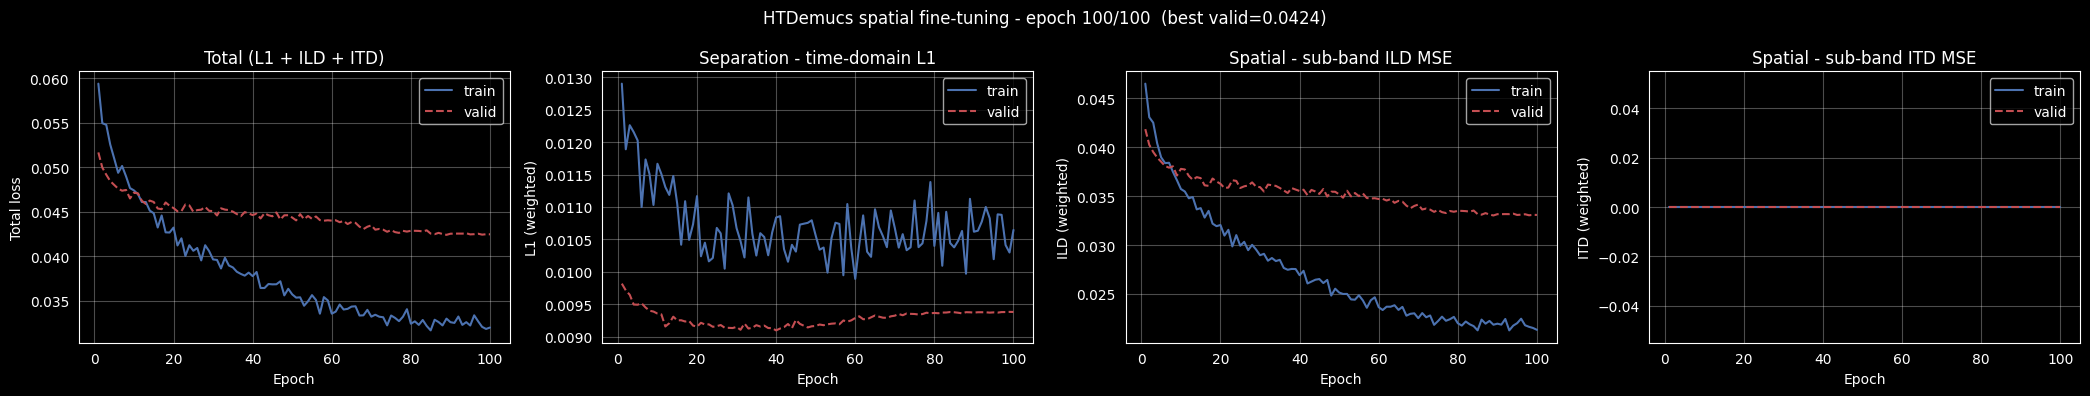

Epoch   86/100  train=0.0329 (td=0.010 ild=0.022 itd=0.000)  valid=0.0425 (td=0.009 ild=0.033 itd=0.000)  lr=4.76e-06  (258s)  <- checkpoint saved
Epoch   87/100  train=0.0326 (td=0.011 ild=0.022 itd=0.000)  valid=0.0426 (td=0.009 ild=0.033 itd=0.000)  lr=4.45e-06  (258s)
Epoch   88/100  train=0.0322 (td=0.010 ild=0.022 itd=0.000)  valid=0.0425 (td=0.009 ild=0.033 itd=0.000)  lr=4.17e-06  (263s)
Epoch   89/100  train=0.0330 (td=0.011 ild=0.022 itd=0.000)  valid=0.0424 (td=0.009 ild=0.033 itd=0.000)  lr=3.90e-06  (260s)  <- checkpoint saved
Epoch   90/100  train=0.0326 (td=0.011 ild=0.022 itd=0.000)  valid=0.0425 (td=0.009 ild=0.033 itd=0.000)  lr=3.66e-06  (260s)
Epoch   91/100  train=0.0325 (td=0.011 ild=0.022 itd=0.000)  valid=0.0425 (td=0.009 ild=0.033 itd=0.000)  lr=3.44e-06  (260s)
Epoch   92/100  train=0.0332 (td=0.011 ild=0.022 itd=0.000)  valid=0.0425 (td=0.009 ild=0.033 itd=0.000)  lr=3.25e-06  (259s)
Epoch   93/100  train=0.0323 (td=0.011 ild=0.021 itd=0.000)  valid=0.0425 (t

In [7]:
history = {
    "train_total": [], "train_td": [], "train_ild": [], "train_itd": [],
    "valid_total": [], "valid_td": [], "valid_ild": [], "valid_itd": [],
    "lr": [],
}
best_valid = math.inf
log_lines  = []   # rolling text log (survives the clear_output redraw)

@torch.no_grad()
def run_valid(model, loader):
    model.eval()
    # Deterministic validation: freeze the RNG so the random crops are
    # identical every epoch (comparable curves), then restore it so the
    # training randomness downstream is unaffected.
    _py_rng = random.getstate()
    _th_rng = torch.get_rng_state()
    random.seed(1234)
    torch.manual_seed(1234)
    tot, td, il, it, n = 0.0, 0.0, 0.0, 0.0, 0
    for mix, targets in loader:
        mix, targets = mix.to(DEVICE), targets.to(DEVICE)
        with autocast("cuda", enabled=USE_AMP):
            estimates = model(mix)    # (B, S, 2, T)
        total, l_td, l_il, l_it = criterion(estimates, targets)
        tot += total.item(); td += l_td.item(); il += l_il.item(); it += l_it.item()
        n   += 1
    random.setstate(_py_rng)
    torch.set_rng_state(_th_rng)
    d = max(n, 1)
    return tot / d, td / d, il / d, it / d

def live_plot(epoch):
    """Redraw the three loss curves in-place and reprint the recent log.

    Uses clear_output(wait=True) so the cell shows a single, continuously
    updated figure instead of stacking one plot per epoch.  `history` and the
    saved checkpoint are untouched, so interrupting the run loses nothing.
    """
    clear_output(wait=True)
    ep = range(1, len(history["train_total"]) + 1)
    fig, axes = plt.subplots(1, 4, figsize=(21, 4))
    panels = [
        ("train_total", "valid_total", "Total (L1 + ILD + ITD)",      "Total loss"),
        ("train_td",    "valid_td",    "Separation - time-domain L1", "L1 (weighted)"),
        ("train_ild",   "valid_ild",   "Spatial - sub-band ILD MSE",  "ILD (weighted)"),
        ("train_itd",   "valid_itd",   "Spatial - sub-band ITD MSE",  "ITD (weighted)"),
    ]
    for ax, (tk, vk, title, ylabel) in zip(axes, panels):
        ax.plot(ep, history[tk], label="train", color="#4c72b0", linewidth=1.5)
        ax.plot(ep, history[vk], label="valid", color="#c44e52", linewidth=1.5, linestyle="--")
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(); ax.grid(True, alpha=0.3)
    fig.suptitle(f"HTDemucs spatial fine-tuning - epoch {epoch}/{N_EPOCHS}  "
                 f"(best valid={best_valid:.4f})")
    plt.tight_layout(); plt.show()
    plt.close(fig)   # free the figure so 100 epochs don't leak memory
    # Reprint the tail of the textual log (cleared by clear_output above)
    print("\n".join(log_lines[-15:]))

# ── Training loop (Ctrl-C / Kernel > Interrupt stops it cleanly) ──────────────
try:
    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        t0 = time.time()
        tot_loss = tot_td = tot_il = tot_it = 0.0
        n_batches = 0

        optimizer.zero_grad()

        for step, (mix, targets) in enumerate(train_loader):
            mix, targets = mix.to(DEVICE), targets.to(DEVICE)

            with autocast("cuda", enabled=USE_AMP):
                estimates = model(mix)                   # (B, S, 2, T)
            # Loss in FP32 (inputs cast inside the loss)
            total, l_td, l_il, l_it = criterion(estimates, targets)
            loss_scaled = total / ACCUM_STEPS

            scaler.scale(loss_scaled).backward()

            tot_loss += total.item(); tot_td += l_td.item()
            tot_il   += l_il.item(); tot_it += l_it.item()
            n_batches += 1

            if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    max_norm=5.0,
                )
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        scheduler.step()

        d = max(n_batches, 1)
        train_total, train_td, train_il, train_it = tot_loss/d, tot_td/d, tot_il/d, tot_it/d
        if valid_loader.dataset:
            valid_total, valid_td, valid_il, valid_it = run_valid(model, valid_loader)
        else:
            valid_total = valid_td = valid_il = valid_it = float("nan")

        history["train_total"].append(train_total); history["train_td"].append(train_td)
        history["train_ild"].append(train_il);      history["train_itd"].append(train_it)
        history["valid_total"].append(valid_total); history["valid_td"].append(valid_td)
        history["valid_ild"].append(valid_il);      history["valid_itd"].append(valid_it)
        history["lr"].append(scheduler.get_last_lr()[0])

        elapsed = time.time() - t0
        log_lines.append(
            f"Epoch {epoch:4d}/{N_EPOCHS}  "
            f"train={train_total:.4f} (td={train_td:.3f} ild={train_il:.3f} itd={train_it:.3f})  "
            f"valid={valid_total:.4f} (td={valid_td:.3f} ild={valid_il:.3f} itd={valid_it:.3f})  "
            f"lr={scheduler.get_last_lr()[0]:.2e}  ({elapsed:.0f}s)"
        )

        # Save best checkpoint (by total validation loss)
        if valid_total < best_valid:
            best_valid = valid_total
            torch.save(
                {
                    "epoch":       epoch,
                    "model_state": model.state_dict(),
                    "optim_state": optimizer.state_dict(),
                    "history":     history,
                    "train_loss":  train_total,
                    "valid_loss":  valid_total,
                    "valid_ild":   valid_il,
                    "valid_itd":   valid_it,
                },
                CKPT_PATH,
            )
            log_lines[-1] += "  <- checkpoint saved"

        # Live in-place redraw of the curves + recent log
        live_plot(epoch)

    print("\nTraining complete.")

except KeyboardInterrupt:
    print(f"\nTraining interrupted by user at epoch {epoch}. "
          f"history and the best checkpoint are preserved.")

print(f"Best validation loss : {best_valid:.4f}")
print(f"Checkpoint           : {CKPT_PATH}")


## Training Curves

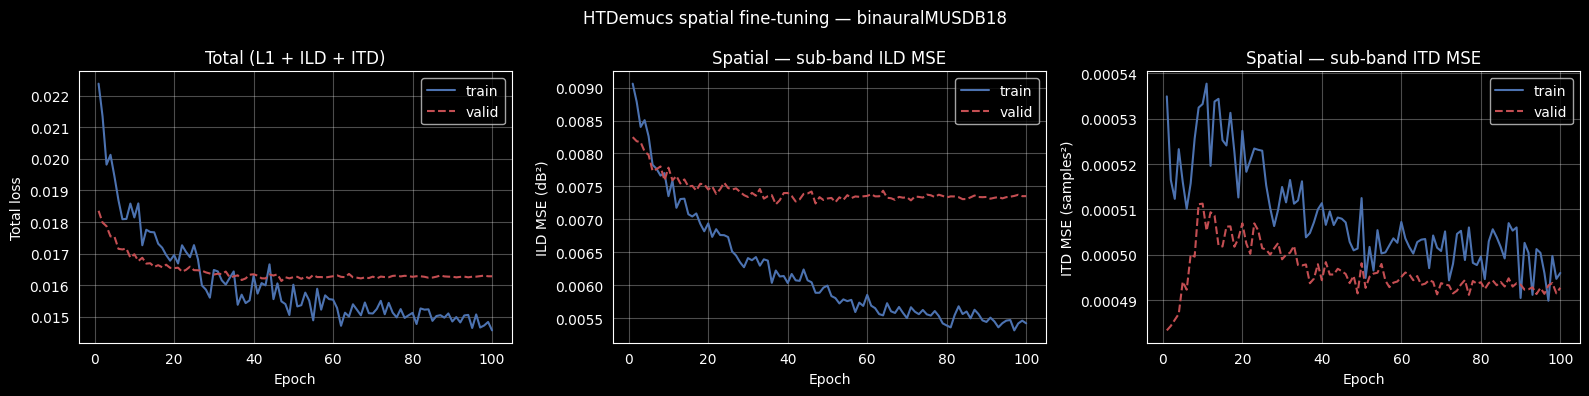

In [19]:
epochs = range(1, len(history["train_total"]) + 1)
fig, axes = plt.subplots(1, 4, figsize=(21, 4))

_panels = [
    ("train_total", "valid_total", "Total (L1 + ILD + ITD)", "Total loss"),
    ("train_td",    "valid_td",    "Separation — time-domain L1", "L1 (weighted)"),
    ("train_ild",   "valid_ild",   "Spatial — sub-band ILD MSE", "ILD MSE (dB²)"),
    ("train_itd",   "valid_itd",   "Spatial — sub-band ITD MSE", "ITD MSE (samples²)"),
]
for ax, (tk, vk, title, ylabel) in zip(axes, _panels):
    ax.plot(epochs, history[tk], label="train", color="#4c72b0", linewidth=1.5)
    ax.plot(epochs, history[vk], label="valid", color="#c44e52", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle("HTDemucs spatial fine-tuning — binauralMUSDB18")
plt.tight_layout()
plt.show()

## Load Checkpoint (run this cell to skip training)

If the fine-tuning was already completed in a previous session, load the saved
weights into `model` instead of re-training.

In [6]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint from {CKPT_PATH}\n"
      f"Epoch {ckpt['epoch']}  "
      f"valid_loss={ckpt['valid_loss']:.4f}  valid_ild={ckpt.get('valid_ild', float('nan')):.4f} "
      f"valid_itd={ckpt.get('valid_itd', float('nan')):.5f}")

Loaded checkpoint from /nas/home/macerbi/sahtdemucs/runs/htdemucs_spatial_finetune/htdemucs_spatial_20260703_142826.pt
Epoch 89  valid_loss=0.0424  valid_ild=0.0330 valid_itd=0.00000


## Evaluation on the Test split - Fine-tuned HTDemucs vs HTDemucs baseline

Each test track is separated **whole** (demucs `apply_model` handles the internal
overlapped chunking), then two metrics are computed per source against the
ground-truth stems:

**SI-SDR** (separation quality)

$$\text{SI-SDR}(\hat{s}, s_{gt}) = 10\log_{10}\!\left(\frac{\big\|\tfrac{\langle \hat{s}, s_{gt}\rangle}{\|s_{gt}\|^2}\,s_{gt}\big\|^2}{\big\|\hat{s} - \tfrac{\langle \hat{s}, s_{gt}\rangle}{\|s_{gt}\|^2}\,s_{gt}\big\|^2}\right)\ \text{[dB]}$$

**Per-band ILD MAE** and **per-band ITD MAE** (spatial-cue preservation) — the
residual level / time-difference error per frequency band, averaged over time:

$$\mathrm{MAE}^{\text{ILD}}_k = \frac{1}{T_f}\sum_t\big|\widehat{\mathrm{ILD}}_k(t) - \mathrm{ILD}_{k,gt}(t)\big|\,[\text{dB}],\qquad
\mathrm{MAE}^{\text{ITD}}_k = \frac{1}{T_f}\sum_t\big|\widehat{\mathrm{ITD}}_k(t) - \mathrm{ITD}_{k,gt}(t)\big|\,[\text{samples}]$$

Both the **fine-tuned HTDemucs** (this run) and the **frozen HTDemucs baseline**
(original pre-trained weights) are run on the same tracks, so the two approaches
are compared on the identical cue definitions used during training.

In [7]:
# Sub-band cue parameters — same as the training loss / SA-HTDemucs config.
_EVAL_N_FFT   = ILD_N_FFT
_EVAL_HOP     = ILD_HOP
_EVAL_BANDS   = ILD_N_BANDS
_EVAL_SCALE   = ILD_BAND_SCALE
_EVAL_SR      = SAMPLE_RATE
_EVAL_MAX_LAG = ITD_MAX_LAG
_EVAL_BETA    = ITD_BETA

def load_stem(path: Path) -> torch.Tensor:
    """Load a WAV and return (2, T) at SAMPLE_RATE."""
    wav, sr = torchaudio.load(str(path))
    if wav.shape[0] == 1:
        wav = wav.repeat(2, 1)
    elif wav.shape[0] > 2:
        wav = wav[:2]
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav

def separate(net: torch.nn.Module, wav: torch.Tensor) -> torch.Tensor:
    """Run an HTDemucs model on a full (2, T) mix. Returns (S, 2, T)."""
    net.eval()
    return apply_model(net, wav.unsqueeze(0), progress=False).squeeze(0)

def compute_si_sdr(est: torch.Tensor, tgt: torch.Tensor) -> float:
    """Scale-invariant SDR in dB between two stereo tensors (2, T)."""
    e = est.float().reshape(-1)
    t = tgt.float().reshape(-1)
    e = e - e.mean()
    t = t - t.mean()
    alpha = (e * t).sum() / (t * t).sum().clamp(min=1e-8)
    proj  = alpha * t
    noise = e - proj
    return 10 * torch.log10((proj ** 2).sum() / (noise ** 2).sum().clamp(min=1e-8)).item()

def compute_ild_bands_mae(est: torch.Tensor, tgt: torch.Tensor) -> np.ndarray:
    """Per-sub-band ILD MAE (n_bands,) between estimated and ground-truth (2, T).

    Uses the same band scale (linear or Mel) as the training loss so the
    evaluation metric is consistent with the objective.
    """
    if _EVAL_SCALE == "mel":
        def _ild_fn(l, r):
            return compute_ild_bands_mel(
                l, r, n_fft=int(_EVAL_N_FFT), hop_length=int(_EVAL_HOP),
                n_bands=int(_EVAL_BANDS), sample_rate=int(_EVAL_SR),
            )
    else:
        def _ild_fn(l, r):
            return compute_ild_bands(
                l, r, n_fft=int(_EVAL_N_FFT), hop_length=int(_EVAL_HOP),
                n_bands=int(_EVAL_BANDS),
            )
    ild_est = _ild_fn(est[0].unsqueeze(0).cpu(), est[1].unsqueeze(0).cpu())
    ild_tgt = _ild_fn(tgt[0].unsqueeze(0).cpu(), tgt[1].unsqueeze(0).cpu())
    return torch.abs(ild_est - ild_tgt).mean(dim=-1).squeeze(0).numpy()   # (n_bands,)

def compute_itd_bands_mae(est: torch.Tensor, tgt: torch.Tensor) -> np.ndarray:
    """Per-sub-band ITD MAE (n_bands,) in samples, between estimated and gt (2, T).

    Same band layout and GCC-PHAT settings as the training loss.
    """
    if _EVAL_SCALE == "mel":
        def _itd_fn(l, r):
            return compute_itd_bands_mel(
                l, r, n_fft=int(_EVAL_N_FFT), hop_length=int(_EVAL_HOP),
                n_bands=int(_EVAL_BANDS), sample_rate=int(_EVAL_SR),
                max_lag=int(_EVAL_MAX_LAG), beta=float(_EVAL_BETA),
            )
    else:
        def _itd_fn(l, r):
            return compute_itd_bands(
                l, r, n_fft=int(_EVAL_N_FFT), hop_length=int(_EVAL_HOP),
                n_bands=int(_EVAL_BANDS),
                max_lag=int(_EVAL_MAX_LAG), beta=float(_EVAL_BETA),
            )
    itd_est = _itd_fn(est[0].unsqueeze(0).cpu(), est[1].unsqueeze(0).cpu())
    itd_tgt = _itd_fn(tgt[0].unsqueeze(0).cpu(), tgt[1].unsqueeze(0).cpu())
    return torch.abs(itd_est - itd_tgt).mean(dim=-1).squeeze(0).numpy()   # (n_bands,)

def evaluate_on_tracks(net: torch.nn.Module, tracks, tag: str) -> dict:
    """Separate every test track with `net` and collect per-source metrics."""
    print(f"Running {tag} on {len(tracks)} test tracks...")
    res = {}
    for idx, track_dir in enumerate(tracks, 1):
        mix_path = track_dir / "mixture.wav"
        if not mix_path.exists():
            print(f"[{idx}/{len(tracks)}] SKIP — no mixture.wav")
            continue
        print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
        t0 = time.perf_counter()

        wav   = load_stem(mix_path).to(DEVICE)
        stems = separate(net, wav).cpu()   # (S, 2, T)

        track_res = {}
        for i, src in enumerate(SOURCES):
            tgt_path = track_dir / f"{src}.wav"
            if not tgt_path.exists():
                continue
            tgt = load_stem(tgt_path)
            est = stems[i]
            T   = min(tgt.shape[-1], est.shape[-1])
            tgt, est = tgt[:, :T], est[:, :T]
            track_res[src] = dict(
                ild_bands_mae=compute_ild_bands_mae(est, tgt),
                itd_bands_mae=compute_itd_bands_mae(est, tgt),
                si_sdr=compute_si_sdr(est, tgt),
            )
        res[track_dir.name] = track_res
        print(f"done ({time.perf_counter() - t0:.1f}s)")
    print(f"{tag}: evaluation complete — {len(res)} tracks.\n")
    return res

# Collect the test tracks
test_dir = DATASET_ROOT / "test"
tracks = sorted((p for p in test_dir.iterdir() if p.is_dir()), key=lambda p: p.name.lower())
print(f"Found {len(tracks)} test tracks.")

Found 50 test tracks.


In [8]:
# Fine-tuned HTDemucs (this run) — `model` already holds the loaded checkpoint.
results = evaluate_on_tracks(model, tracks, tag="Fine-tuned HTDemucs")

Running Fine-tuned HTDemucs on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (31.5s)
[2/50] AM Contra - Heart Peripheral ... done (13.1s)
[3/50] Angels In Amplifiers - I'm Alright ... done (11.2s)
[4/50] Arise - Run Run Run ... done (13.8s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (16.0s)
[6/50] BKS - Bulldozer ... done (20.7s)
[7/50] BKS - Too Much ... done (13.6s)
[8/50] Bobby Nobody - Stitch Up ... done (13.7s)
[9/50] Buitraker - Revo X ... done (17.0s)
[10/50] Carlos Gonzalez - A Place For Us ... done (15.4s)
[11/50] Cristina Vane - So Easy ... done (15.7s)
[12/50] Detsky Sad - Walkie Talkie ... done (11.6s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (11.6s)
[14/50] Forkupines - Semantics ... done (16.6s)
[15/50] Georgia Wonder - Siren ... done (26.2s)
[16/50] Girls Under Glass - We Feel Alright ... done (19.4s)
[17/50] Hollow Ground - Ill Fate ... done (8.9s)
[18/50] James Elder & Mark M Thompson - The English Actor ... done (12.9s

## HTDemucs Baseline Evaluation

Run the **frozen, original pre-trained HTDemucs** (fresh weights, no fine-tuning)
on the same test tracks to build `results_baseline` with the same structure as
`results`.

In [9]:
# Fresh pre-trained HTDemucs as the spatial baseline
baseline_bag = get_model("htdemucs")
baseline = baseline_bag.models[0] if hasattr(baseline_bag, "models") else baseline_bag
baseline = baseline.to(DEVICE).eval()

results_baseline = evaluate_on_tracks(baseline, tracks, tag="HTDemucs baseline")

Running HTDemucs baseline on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (10.7s)
[2/50] AM Contra - Heart Peripheral ... done (11.2s)
[3/50] Angels In Amplifiers - I'm Alright ... done (9.4s)
[4/50] Arise - Run Run Run ... done (11.7s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (13.3s)
[6/50] BKS - Bulldozer ... done (17.9s)
[7/50] BKS - Too Much ... done (11.8s)
[8/50] Bobby Nobody - Stitch Up ... done (11.8s)
[9/50] Buitraker - Revo X ... done (14.9s)
[10/50] Carlos Gonzalez - A Place For Us ... done (13.2s)
[11/50] Cristina Vane - So Easy ... done (13.5s)
[12/50] Detsky Sad - Walkie Talkie ... done (10.3s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (10.0s)
[14/50] Forkupines - Semantics ... done (14.6s)
[15/50] Georgia Wonder - Siren ... done (23.6s)
[16/50] Girls Under Glass - We Feel Alright ... done (16.9s)
[17/50] Hollow Ground - Ill Fate ... done (7.6s)
[18/50] James Elder & Mark M Thompson - The English Actor ... done (10.8s)
[

## SI-SDR per Source - Fine-tuned vs Baseline

Checks that separation quality is preserved after the spatial fine-tuning:
SI-SDR should stay close to the HTDemucs baseline while the ILD MAE (next
section) drops.

In [10]:
def _aggregate(res):
    ag = {src: {"ild_bands_mae": [], "itd_bands_mae": [], "si_sdr": []} for src in SOURCES}
    for track_res in res.values():
        for src, m in track_res.items():
            ag[src]["ild_bands_mae"].append(m["ild_bands_mae"])
            ag[src]["itd_bands_mae"].append(m["itd_bands_mae"])
            ag[src]["si_sdr"].append(m["si_sdr"])
    return ag

def _stats(ag):
    return {
        "mean_si_sdr":        {s: float(np.mean(ag[s]["si_sdr"])) for s in SOURCES},
        "mean_ild_mae":       {s: float(np.mean(ag[s]["ild_bands_mae"])) for s in SOURCES},
        "mean_itd_mae":       {s: float(np.mean(ag[s]["itd_bands_mae"])) for s in SOURCES},
        "mean_ild_mae_bands": {s: np.mean(ag[s]["ild_bands_mae"], axis=0) for s in SOURCES},
        "mean_itd_mae_bands": {s: np.mean(ag[s]["itd_bands_mae"], axis=0) for s in SOURCES},
    }

agg          = _aggregate(results)
agg_baseline = _aggregate(results_baseline)
stats        = _stats(agg)
stats_bl     = _stats(agg_baseline)

def _mean_all(st, key):
    return float(np.mean([st[key][s] for s in SOURCES]))

# ITD is stored in samples (the loss unit); display it in microseconds.
_US = 1e6 / SAMPLE_RATE   # µs per sample (≈ 22.68 µs @ 44.1 kHz)

print("Fine-tuned HTDemucs vs HTDemucs baseline")
print("SI-SDR [dB]  |  scalar ILD MAE [dB]  |  scalar ITD MAE [µs]")
print(f"{'Source':<9}| {'SI ft':>7} {'SI bl':>7} {'dSI':>6} | "
      f"{'ILD ft':>7} {'ILD bl':>7} {'dILD':>6} | {'ITD ft':>8} {'ITD bl':>8} {'dITD':>7}")
print("-" * 90)
for src in SOURCES:
    si_ft, si_bl = stats["mean_si_sdr"][src], stats_bl["mean_si_sdr"][src]
    il_ft, il_bl = stats["mean_ild_mae"][src], stats_bl["mean_ild_mae"][src]
    it_ft = stats["mean_itd_mae"][src] * _US
    it_bl = stats_bl["mean_itd_mae"][src] * _US
    print(f"{src:<9}| {si_ft:>+7.2f} {si_bl:>+7.2f} {si_ft - si_bl:>+6.2f} | "
          f"{il_ft:>7.3f} {il_bl:>7.3f} {il_ft - il_bl:>+6.3f} | "
          f"{it_ft:>8.1f} {it_bl:>8.1f} {it_ft - it_bl:>+7.1f}")
print("-" * 90)
si_ft, si_bl = _mean_all(stats, "mean_si_sdr"),  _mean_all(stats_bl, "mean_si_sdr")
il_ft, il_bl = _mean_all(stats, "mean_ild_mae"), _mean_all(stats_bl, "mean_ild_mae")
it_ft = _mean_all(stats, "mean_itd_mae") * _US
it_bl = _mean_all(stats_bl, "mean_itd_mae") * _US
print(f"{'All':<9}| {si_ft:>+7.2f} {si_bl:>+7.2f} {si_ft - si_bl:>+6.2f} | "
      f"{il_ft:>7.3f} {il_bl:>7.3f} {il_ft - il_bl:>+6.3f} | "
      f"{it_ft:>8.1f} {it_bl:>8.1f} {it_ft - it_bl:>+7.1f}")
print("\ndSI > 0 -> separation preserved/improved;  dILD/dITD < 0 -> spatial cues improved.")

Fine-tuned HTDemucs vs HTDemucs baseline
SI-SDR [dB]  |  scalar ILD MAE [dB]  |  scalar ITD MAE [µs]
Source   |   SI ft   SI bl    dSI |  ILD ft  ILD bl   dILD |   ITD ft   ITD bl    dITD
------------------------------------------------------------------------------------------
drums    |   +8.69   +9.77  -1.08 |   5.727   6.475 -0.747 |    412.1    408.5    +3.6
bass     |   +8.05   +7.67  +0.37 |   3.921   6.576 -2.656 |    418.5    438.8   -20.3
other    |   +3.67   +4.31  -0.64 |   5.897   6.292 -0.396 |    405.4    396.9    +8.5
vocals   |   +7.21   +7.91  -0.70 |   5.836   5.957 -0.122 |    354.3    368.6   -14.3
------------------------------------------------------------------------------------------
All      |   +6.91   +7.42  -0.51 |   5.345   6.325 -0.980 |    397.6    403.2    -5.6

dSI > 0 -> separation preserved/improved;  dILD/dITD < 0 -> spatial cues improved.


## Mean per-band ILD & ITD MAE over the test set

For band $k$ and source $s$, the plotted value is the mean absolute cue error
across all $N$ test tracks. **Top row: ILD MAE** (dB); **bottom row: ITD MAE**
(µs — the loss uses samples internally, converted here for readability via
$1\,\text{sample} = 10^6/f_s\ \mu s \approx 22.7\,\mu s$ @ 44.1 kHz). Left column:
the **fine-tuned HTDemucs**; right column: the **frozen baseline**. Lower curves
mean better spatial-cue preservation.

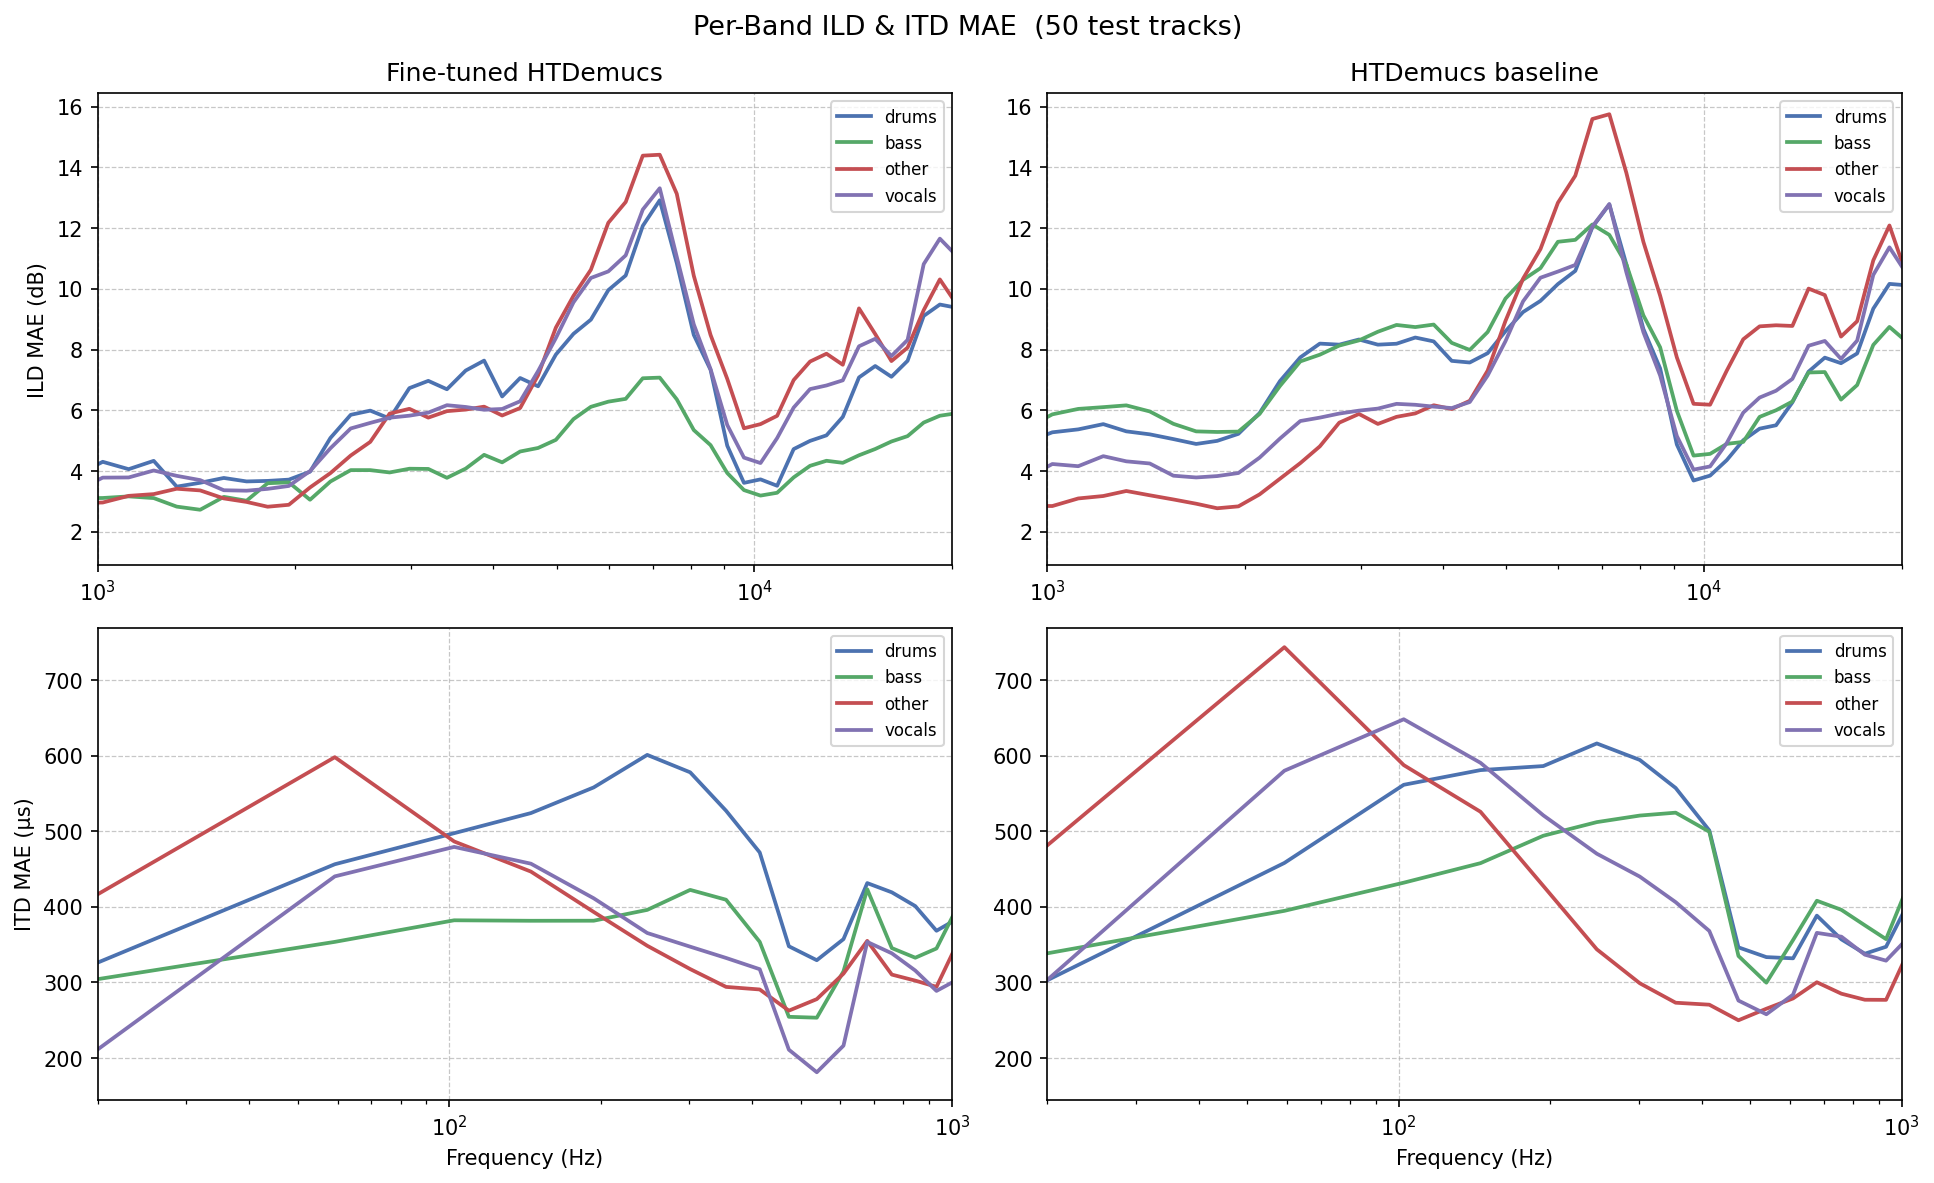

In [11]:
n_bands = len(next(iter(stats["mean_ild_mae_bands"].values())))

# Band centre frequencies (x-axis): mean Hz per Mel band, or linear midpoints.
if _EVAL_SCALE == "mel":
    _ba     = mel_bin_assignment(int(_EVAL_N_FFT), n_bands, int(_EVAL_SR))
    _bin_hz = np.arange(int(_EVAL_N_FFT) // 2 + 1) * (int(_EVAL_SR) / int(_EVAL_N_FFT))
    band_hz = np.array([
        _bin_hz[(_ba == m).numpy()].mean() if (_ba == m).any() else 0.0
        for m in range(n_bands)
    ])
else:
    band_hz = np.linspace(0, SAMPLE_RATE / 2, n_bands, endpoint=False)

# ITD is stored in samples (the loss unit); display it in microseconds.
_US = 1e6 / SAMPLE_RATE   # µs per sample (≈ 22.68 µs @ 44.1 kHz)

# Rows: (metric key, y-label, display scale);  Columns: (stats dict, title)
_rows = [
    ("mean_ild_mae_bands", "ILD MAE (dB)", 1.0,  (1000, 20000)),
    ("mean_itd_mae_bands", "ITD MAE (µs)", _US,  (20, 1000)),
]
_cols = [(stats, "Fine-tuned HTDemucs"), (stats_bl, "HTDemucs baseline")]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=150)
for r, (mkey, ylabel, scale, xlim) in enumerate(_rows):
    for c, (st, title) in enumerate(_cols):
        ax = axes[r, c]
        for i, src in enumerate(SOURCES):
            ax.plot(band_hz, st[mkey][src] * scale, label=src, color=COLORS[i], lw=1.8)
        ax.set_xscale("log")
        ax.set_ylabel(ylabel if c == 0 else "")
        if r == 0:
            ax.set_title(title)
        if r == len(_rows) - 1:
            ax.set_xlabel("Frequency (Hz)")
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
    # Share y-scale across the two columns of a row for fair comparison.
    y0 = min(axes[r, 0].get_ylim()[0], axes[r, 1].get_ylim()[0])
    y1 = max(axes[r, 0].get_ylim()[1], axes[r, 1].get_ylim()[1])
    axes[r, 0].set_ylim(y0, y1); axes[r, 1].set_ylim(y0, y1)
    axes[r, 0].set_xlim(xlim)
    axes[r, 1].set_xlim(xlim)

plt.suptitle(f"Per-Band ILD & ITD MAE  ({len(results)} test tracks)", fontsize=13)
plt.tight_layout()
plt.show()